## **POS Tagging**

In [2]:
# 1. Install Library
!pip install stanza tqdm pandas

# 2. Import Library
import pandas as pd
import stanza
from tqdm import tqdm

# Aktifkan progress bar
tqdm.pandas()

# 3. Load Dataset
print("Membaca dataset...")
df_sentimen_banjir = pd.read_csv('df_sentimen_banjir_processed.csv')
df_sentimen_bandang = pd.read_csv('df_sentimen_bandang_processed.csv')

# 4. Download dan Load Model Stanza Bahasa Indonesia
print("Mendownload dan menyiapkan model Stanza...")
stanza.download('id')
nlp_stanza = stanza.Pipeline('id', processors='tokenize,pos', use_gpu=True)

# 5. Fungsi POS Tagging Stanza
def pos_tagging_stanza(text):
    if isinstance(text, str) and text.strip() != "":
        # Memproses teks
        doc = nlp_stanza(text)
        result = []
        for sentence in doc.sentences:
            for word in sentence.words:
                result.append((word.text, word.upos))
        return result
    return []

# 6. Eksekusi POS Tagging
print("Memproses POS Tagging untuk data banjir biasa...")
df_sentimen_banjir['POS_Tags'] = df_sentimen_banjir['After_lemma'].progress_apply(pos_tagging_stanza)

print("Memproses POS Tagging untuk data banjir bandang...")
df_sentimen_bandang['POS_Tags'] = df_sentimen_bandang['After_lemma'].progress_apply(pos_tagging_stanza)

# 7. Simpan Hasil ke CSV Baru
print("Menyimpan hasil...")
df_sentimen_banjir.to_csv('hasil_pos_banjir_biasa.csv', index=False)
df_sentimen_bandang.to_csv('hasil_pos_banjir_bandang.csv', index=False)

print("\nProses selesai! File 'hasil_pos_banjir_biasa.csv' dan 'hasil_pos_banjir_bandang.csv' sudah tersimpan.")
display(df_sentimen_banjir[['After_lemma', 'POS_Tags']].head(3))

Membaca dataset...
Mendownload dan menyiapkan model Stanza...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package    |
--------------------------
| tokenize  | gsd        |
| mwt       | gsd        |
| pos       | gsd_charlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Done loading processors!


Memproses POS Tagging untuk data banjir biasa...


100%|██████████| 511/511 [02:58<00:00,  2.87it/s]


Memproses POS Tagging untuk data banjir bandang...


100%|██████████| 974/974 [07:03<00:00,  2.30it/s]


Menyimpan hasil...

Proses selesai! File 'hasil_pos_banjir_biasa.csv' dan 'hasil_pos_banjir_bandang.csv' sudah tersimpan.


,After_lemma,POS_Tags
0,wali kota makasar munafri api arifudin tetap s...,"[(wali, NOUN), (kota, NOUN), (makasar, NOUN), ..."
1,jumlah ruas jalan kota makasar sulawesi selata...,"[(jumlah, NOUN), (ruas, NOUN), (jalan, NOUN), ..."
2,badan penangulangan bencana daerah bpbd makasa...,"[(badan, NOUN), (penangulangan, NOUN), (bencan..."


**Visualisasi POS Tagging**

In [3]:
import ast
from IPython.display import HTML, display

def visualize_pos_tags_highlight(pos_data, max_tokens=150):
    if isinstance(pos_data, str):
        try:
            pos_list = ast.literal_eval(pos_data)
        except:
            return "<p>Gagal membaca format data.</p>"
    else:
        pos_list = pos_data

    if not isinstance(pos_list, list):
        return "<p>Data tidak tersedia.</p>"

    pos_list = pos_list[:max_tokens]

    color_map = {
        'NN': '#e2f0cb', 'NOUN': '#e2f0cb', 'NND': '#e2f0cb',
        'NNP': '#cce3f6', 'PROPN': '#cce3f6',
        'VB': '#ffdfd3', 'VERB': '#ffdfd3',
        'JJ': '#fdfd96', 'ADJ': '#fdfd96',
        'RB': '#c5eaee', 'ADV': '#c5eaee',
        'CD': '#ffb347', 'OD': '#ffb347', 'NUM': '#ffb347',
        'PR': '#e2d9f3', 'PRP': '#e2d9f3', 'PRON': '#e2d9f3',
        'IN': '#f0f0f0', 'ADP': '#f0f0f0',
        'CC': '#f0f0f0', 'SC': '#f0f0f0', 'CCONJ': '#f0f0f0', 'SCONJ': '#f0f0f0'
    }

    html_content = ""
    for word, tag in pos_list:
        # Hapus spasi dan jadikan huruf besar agar cocok dengan color_map
        clean_tag = tag.strip().upper()
        bg_color = color_map.get(clean_tag, '#ffffff')

        html_content += f"""
        <span style="background-color: {bg_color}; border: 1px solid #bbb; border-radius: 4px; padding: 2px 6px; margin: 3px; display: inline-block; font-family: sans-serif; box-shadow: 1px 1px 2px rgba(0,0,0,0.05);">
            <span style="font-weight: bold; color: #000; font-size: 14px;">{word}</span>
            <span style="font-size: 10px; font-weight: 800; color: #444; margin-left: 3px;">[{clean_tag}]</span>
        </span>
        """
    return html_content

In [4]:
sample_index = 0

# Menggunakan dataframe 'df_sentimen_banjir' dan kolom 'POS_Tags'
html_pos = visualize_pos_tags_highlight(
    df_sentimen_banjir.loc[sample_index, 'POS_Tags'],
    max_tokens=150
)

display(HTML(f"""
<h3>POS Tagging Visualization</h3>
<div style="line-height:2.1; font-size:15px; padding:10px; border-radius:8px;">
{html_pos}
</div>
"""))

TAG            BANJIR        %      BANDANG        %
NOUN           83,854    70.3%      189,898    67.8%
PROPN           3,677     3.1%       14,951     5.3%
VERB            8,781     7.4%       19,920     7.1%
ADJ             7,954     6.7%       21,470     7.7%
ADV             3,733     3.1%        8,099     2.9%
OD/NUM          1,249     1.0%        2,871     1.0%
PRP             1,037     0.9%        2,739     1.0%
ADP             3,511     2.9%        7,191     2.6%
SC                998     0.8%        1,667     0.6%
TOTAL         119,280             280,000


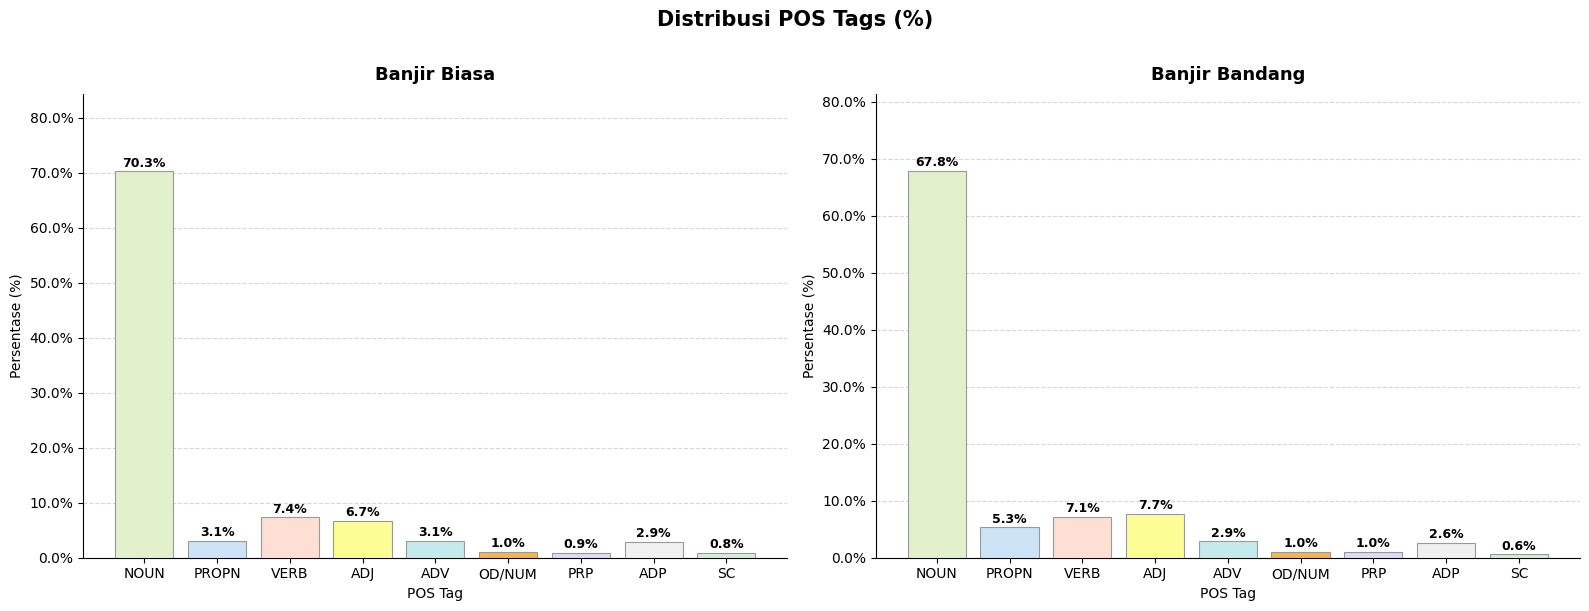

Plot tersimpan sebagai 'distribusi_pos_tags.png'


In [5]:
# Distribusi & Persentase POS Tags

import ast
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- Konfigurasi ---
TARGET_TAGS = ['NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV', 'NUM', 'PRON', 'ADP', 'SCONJ']
LABEL_MAP = {
    'NOUN': 'NOUN', 'PROPN': 'PROPN', 'VERB': 'VERB',
    'ADJ': 'ADJ', 'ADV': 'ADV', 'NUM': 'OD/NUM',
    'PRON': 'PRP', 'ADP': 'ADP', 'SCONJ': 'SC'
}
COLOR_MAP = {
    'NOUN': '#e2f0cb', 'PROPN': '#cce3f6', 'VERB': '#ffdfd3',
    'ADJ': '#fdfd96', 'ADV': '#c5eaee', 'NUM': '#ffb347',
    'PRON': '#e2d9f3', 'ADP': '#f0f0f0', 'SCONJ': '#d4edda'
}

def count_pos_tags(series):
    """Hitung total kemunculan setiap POS tag dari kolom POS_Tags."""
    counts = {tag: 0 for tag in TARGET_TAGS}
    total = 0
    for pos_data in series:
        if isinstance(pos_data, str):
            try:
                pos_list = ast.literal_eval(pos_data)
            except:
                continue
        else:
            pos_list = pos_data
        if not isinstance(pos_list, list):
            continue
        for _, tag in pos_list:
            clean = tag.strip().upper()
            total += 1
            if clean in counts:
                counts[clean] += 1
    return counts, total

def plot_pos_distribution(counts, total, title, ax):
    tags   = list(counts.keys())
    labels = [LABEL_MAP[t] for t in tags]
    percs  = [(counts[t] / total * 100) if total > 0 else 0 for t in tags]
    colors = [COLOR_MAP[t] for t in tags]

    bars = ax.bar(labels, percs, color=colors, edgecolor='#999', linewidth=0.8, zorder=3)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Persentase (%)', fontsize=10)
    ax.set_xlabel('POS Tag', fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.set_ylim(0, max(percs) * 1.2 if percs else 10)
    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

    for bar, pct in zip(bars, percs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

# --- Hitung ---
counts_banjir,   total_banjir   = count_pos_tags(df_sentimen_banjir['POS_Tags'])
counts_bandang,  total_bandang  = count_pos_tags(df_sentimen_bandang['POS_Tags'])

# --- Print ringkasan ---
print("=" * 45)
print(f"{'TAG':<10} {'BANJIR':>10} {'%':>8}   {'BANDANG':>10} {'%':>8}")
print("=" * 45)
for tag in TARGET_TAGS:
    p1 = counts_banjir[tag]  / total_banjir   * 100 if total_banjir   else 0
    p2 = counts_bandang[tag] / total_bandang  * 100 if total_bandang  else 0
    print(f"{LABEL_MAP[tag]:<10} {counts_banjir[tag]:>10,} {p1:>7.1f}%   {counts_bandang[tag]:>10,} {p2:>7.1f}%")
print("=" * 45)
print(f"{'TOTAL':<10} {total_banjir:>10,}          {total_bandang:>10,}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle('Distribusi POS Tags (%)', fontsize=15, fontweight='bold', y=1.01)

plot_pos_distribution(counts_banjir,  total_banjir,  'Banjir Biasa',  axes[0])
plot_pos_distribution(counts_bandang, total_bandang, 'Banjir Bandang', axes[1])

plt.tight_layout()
plt.savefig('distribusi_pos_tags.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot tersimpan sebagai 'distribusi_pos_tags.png'")

## **Named Entity Recognition (NER)**

In [7]:
# 1. Install Library
!pip install transformers tqdm pandas

# 2. Import Library
import pandas as pd
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from tqdm import tqdm

# Aktifkan progress bar pandas
tqdm.pandas()

# 3. Load Dataset Berita
print("Membaca dataset berita...")
df_berita = pd.read_csv('data_berita_banjir_scraped.csv')

# Tangani baris yang kosong (NaN) di kolom 'Konten' agar tidak error saat diproses
df_berita['Konten'] = df_berita['Konten'].fillna("").astype(str)

# 4. Inisialisasi Model IndoBERT
print("Memuat model NER IndoBERT...")
model_name = "cahya/bert-base-indonesian-NER"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# 5. Fungsi Ekstraksi NER dengan Chunking
# (Sangat penting untuk menghindari error batas maksimal token dari model BERT)
def extract_entities_chunked(text, chunk_size=300):
    chunks = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
    results = []

    for chunk in chunks:
        try:
            ents = ner_pipeline(chunk)
            results.extend([(ent['word'], ent['entity_group']) for ent in ents])
        except Exception as e:
            continue

    return results

# 6. Eksekusi Ekstraksi NER
print("Mulai mengekstrak entitas NER pada kolom 'Konten'...")
# Catatan: Karena menggunakan deep learning, proses ini mungkin memakan waktu.
# GPU (T4) yang kamu aktifkan sebelumnya akan sangat membantu mempercepat proses ini.
df_berita['entities'] = df_berita['Konten'].progress_apply(extract_entities_chunked)

# 7. Format Menjadi Dataframe Detail untuk Analisis
print("Menyusun ulang format data...")
rows = []
for idx, row in df_berita.iterrows():
    if isinstance(row['entities'], list):
        for text, ent_type in row['entities']:
            rows.append({
                'id_berita': idx,
                'entitas': text,
                'label': ent_type
            })

df_ner_detail = pd.DataFrame(rows)

# 8. Simpan Hasil ke CSV Baru
print("Menyimpan hasil ekstraksi NER...")
df_ner_detail.to_csv('hasil_ner_berita.csv', index=False)

print("\nProses selesai! File 'hasil_ner_berita.csv' sudah tersimpan.")
display(df_ner_detail.head(10))

Membaca dataset berita...
Memuat model NER IndoBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Mulai mengekstrak entitas NER pada kolom 'Konten'...



  0%|          | 0/2454 [00:00<?, ?it/s]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset

100%|██████████| 2454/2454 [02:48<00:00, 14.57it/s]


Menyusun ulang format data...
Menyimpan hasil ekstraksi NER...

Proses selesai! File 'hasil_ner_berita.csv' sudah tersimpan.


,id_berita,entitas,label
0,3,wali kota makassar,NOR
1,3,munafri ' appi ' arifuddin,PER
2,3,kelurahan katimbang,GPE
3,3,paccerakkang,GPE
4,3,kecamatan biringkanaya,GPE
5,3,kota makassar,GPE
6,3,app,PER
7,3,##i,ORG
8,3,kantor balai kota makassar,LOC
9,3,senin ( 12 / 1 / 2026 ),DAT


**Visualisasi NER**

In [22]:
import pandas as pd
import re
from IPython.display import HTML, display

# 1. Load Data
print("Membaca data...")
df_berita = pd.read_csv('data_berita_banjir_scraped.csv')
df_ner = pd.read_csv('hasil_ner_berita.csv')

# 2. Fungsi Visualisasi Inline NER
def visualize_ner_inline(id_berita, df_text, df_entities):
    # Ambil teks asli dari kolom 'Konten'
    try:
        teks_asli = str(df_text.loc[id_berita, 'Konten'])
    except KeyError:
        return "Error: Kolom 'Konten' tidak ditemukan. Pastikan nama kolom teks benar."

    # Ambil daftar entitas khusus untuk ID berita ini saja
    entitas_berita = df_entities[df_entities['id_berita'] == id_berita].copy()

    if entitas_berita.empty:
        return f"Tidak ada entitas yang ditemukan untuk ID berita {id_berita}."

    # PENTING: Urutkan entitas dari karakter terpanjang ke terpendek
    # Ini untuk mencegah bug replace ganda (misal 'Kota Makassar' harus di-replace lebih dulu daripada kata 'Makassar' saja)
    entitas_berita = entitas_berita.sort_values(by="entitas", key=lambda x: x.astype(str).str.len(), ascending=False)

    # Mapping Warna (Sesuai dengan gaya di screenshot)
    color_map = {
        'PER': '#cce3f6',   # Biru muda (Tokoh/Orang)
        'ORG': '#e2f0cb',   # Hijau muda (Organisasi)
        'GPE': '#ffdfd3',   # Pink (Geopolitik/Wilayah)
        'LOC': '#ffdfd3',   # Pink (Lokasi geografis)
        'DAT': '#fdfd96',   # Kuning (Tanggal)
        'TIM': '#fdfd96',   # Kuning (Waktu)
        'QTY': '#ffb347',   # Oranye (Kuantitas)
        'CRD': '#ffb347',   # Oranye (Angka)
        'NOR': '#e2d9f3',   # Ungu muda (Norma/Jabatan)
        'EVT': '#f5c8df',   # Pink keunguan (Event/Kejadian)
        'PRD': '#c5eaee',   # Cyan (Produk)
    }

    teks_highlight = teks_asli
    replacements = {} # Menyimpan tag HTML sementara

    # Proses pencarian dan penggantian teks
    for idx, row in entitas_berita.iterrows():
        kata = str(row['entitas']).strip()
        label = str(row['label']).strip().upper()

        if not kata or kata.lower() == 'nan':
            continue

        warna = color_map.get(label, '#e0e0e0') # Default abu-abu

        # Desain kotak warna persis seperti displaCy / Screenshot
        html_tag = f"""<mark style="background-color: {warna}; padding: 3px 6px; border-radius: 5px; margin: 0 2px; display: inline-block; box-shadow: 1px 1px 3px rgba(0,0,0,0.1); border: 1px solid rgba(0,0,0,0.05);">
        <span style="font-weight: 600; color: #222;">{kata}</span>
        <span style="font-size: 0.7em; font-weight: 800; color: #555; margin-left: 2px;">[{label}]</span>
        </mark>"""

        # Gunakan regex case-insensitive & placeholder agar tag HTML tidak rusak tumpang tindih
        placeholder = f"[[[PLACEHOLDER_{idx}]]]"
        replacements[placeholder] = html_tag

        # Escape special character dan ganti kata di teks dengan placeholder
        escaped_kata = re.escape(kata)
        teks_highlight = re.sub(f'(?i){escaped_kata}', placeholder, teks_highlight)

    # Kembalikan placeholder menjadi tag HTML yang sebenarnya
    for placeholder, tag in replacements.items():
        teks_highlight = teks_highlight.replace(placeholder, tag)

    return teks_highlight

# ==========================================
# 3. EKSEKUSI VISUALISASI
# ==========================================

# Aku set ID-nya ke 3 karena berita Wali Kota Makassar (seperti di screenshot-mu) itu ada di ID 3!
id_pilihan = 3

html_result = visualize_ner_inline(id_pilihan, df_berita, df_ner)

display(HTML(f"""
<h3 style="font-family: sans-serif; color: #333;">Visualisasi Inline NER (ID Berita: {id_pilihan})</h3>
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 2.4; font-size: 15.5px; padding: 25px; background-color: #fafafa; border: 1px solid #ddd; border-radius: 10px; color: #333;">
    {html_result}
</div>
"""))

Membaca data...


**Analisis NER**

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_banjir = pd.read_csv('df_sentimen_banjir_processed.csv')
df_bandang = pd.read_csv('df_sentimen_bandang_processed.csv')
df_ner = pd.read_csv('hasil_ner_berita.csv')

# 2. Gabungkan & Mapping ID ke Sentimen
df_all = pd.concat([df_banjir, df_bandang], ignore_index=True)
df_mapping = df_all[['Sentimen']].copy()
df_mapping['id_berita'] = df_mapping.index

df_ner_merged = df_ner.merge(df_mapping, on='id_berita', how='left')
df_ner_merged['entitas'] = df_ner_merged['entitas'].astype(str).str.replace('##', '').str.strip().str.lower()

df_ner_banjir = df_ner_merged[df_ner_merged['Sentimen'] == 'Banjir']
df_ner_bandang = df_ner_merged[df_ner_merged['Sentimen'] == 'Bandang']

# 3. Fungsi Plot Grafik Bersebelahan
def plot_ner_comparison(df, label_ner, title_kategori, ax, palette_color):
    top_10 = df[df['label'] == label_ner]['entitas'].value_counts().head(10)

    if not top_10.empty:
        sns.barplot(x=top_10.values, y=top_10.index, palette=palette_color, ax=ax)
        ax.set_title(f'Top 10 {label_ner} - {title_kategori}', fontweight='bold')
        ax.set_xlabel('Frekuensi')
        ax.set_ylabel('Entitas')
        ax.grid(axis='x', linestyle='--', alpha=0.6)

print("Data dan fungsi siap!")

Data dan fungsi siap!


Analisis Lokasi:

/tmp/ipykernel_2366/60756497.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette=palette_color, ax=ax)
/tmp/ipykernel_2366/60756497.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette=palette_color, ax=ax)


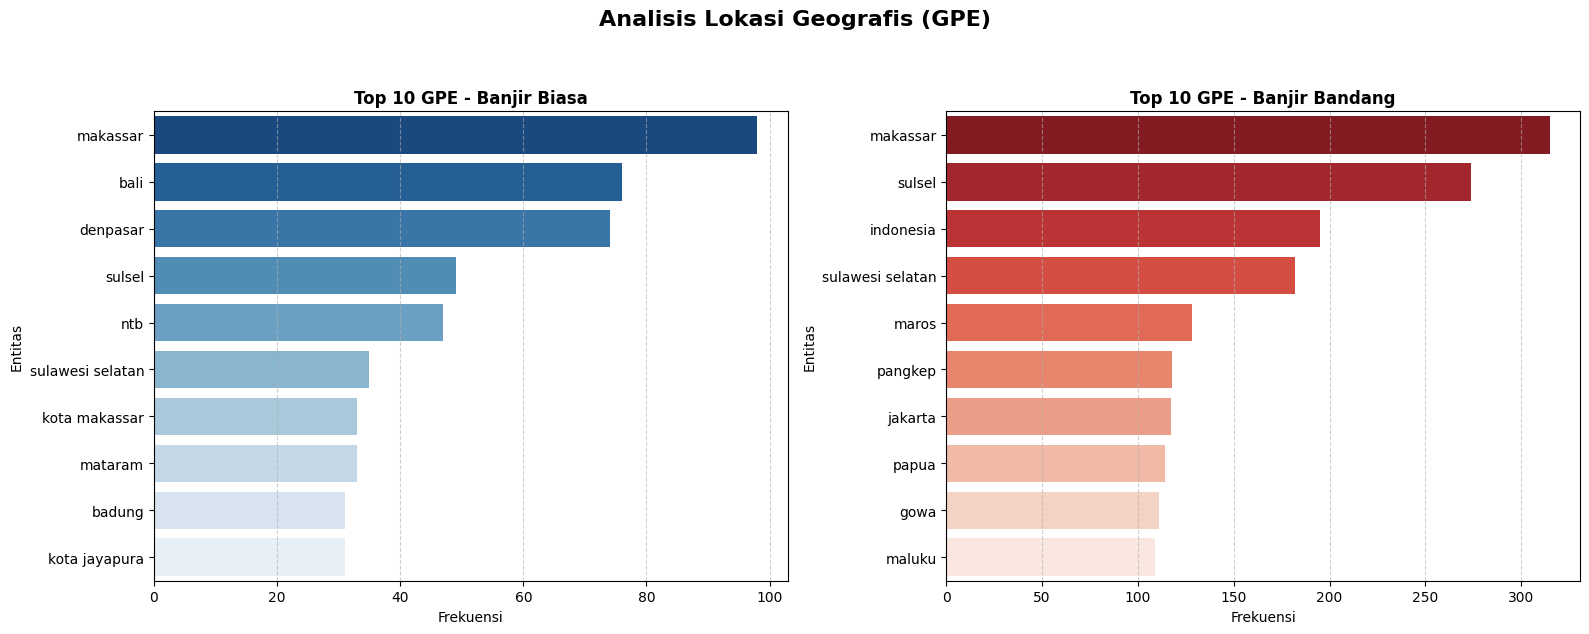

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Lokasi Geografis (GPE)', fontsize=16, fontweight='bold', y=1.05)

# Kiri: Biasa, Kanan: Bandang
plot_ner_comparison(df_ner_banjir, 'GPE', 'Banjir Biasa', axes[0], 'Blues_r')
plot_ner_comparison(df_ner_bandang, 'GPE', 'Banjir Bandang', axes[1], 'Reds_r')

plt.tight_layout()
plt.show()

Analisis Instansi/Organisasi:

/tmp/ipykernel_2366/60756497.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette=palette_color, ax=ax)
/tmp/ipykernel_2366/60756497.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette=palette_color, ax=ax)


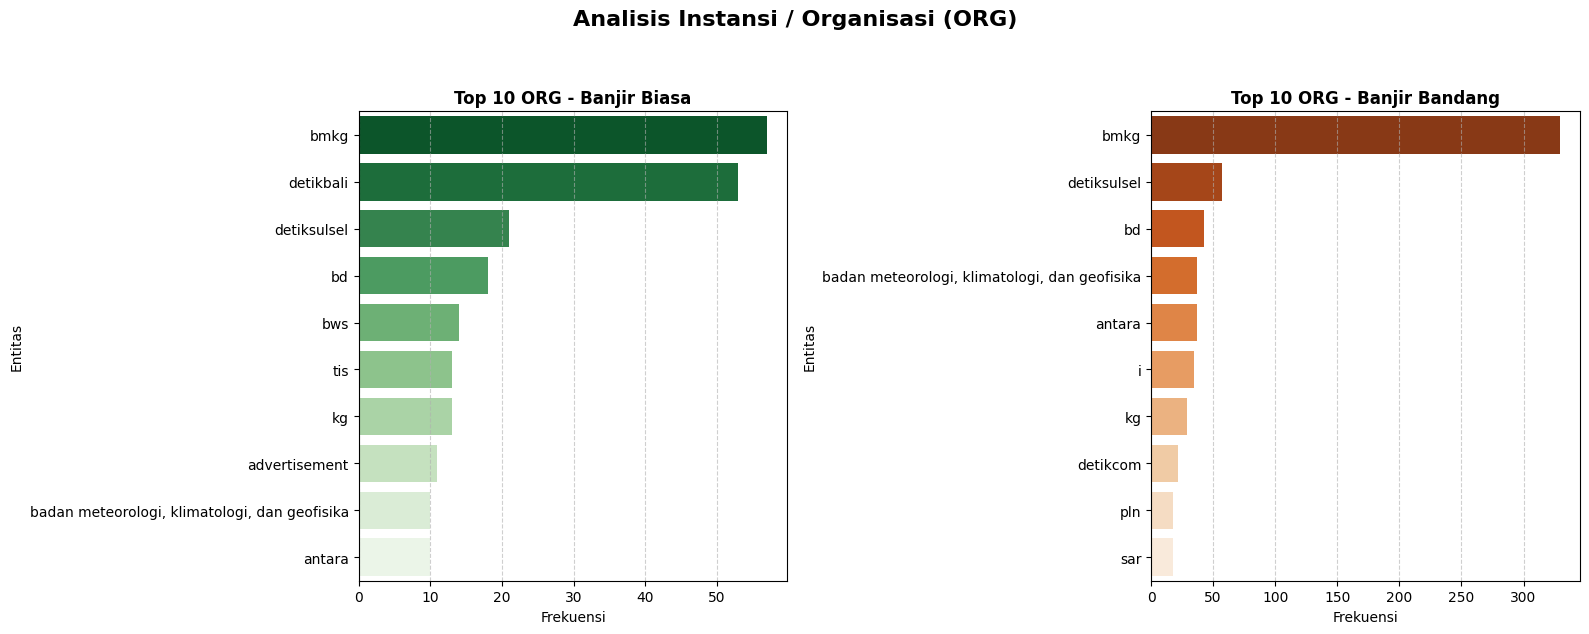

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Instansi / Organisasi (ORG)', fontsize=16, fontweight='bold', y=1.05)

# Kiri: Biasa, Kanan: Bandang
plot_ner_comparison(df_ner_banjir, 'ORG', 'Banjir Biasa', axes[0], 'Greens_r')
plot_ner_comparison(df_ner_bandang, 'ORG', 'Banjir Bandang', axes[1], 'Oranges_r')

plt.tight_layout()
plt.show()

Analisis Tokoh/Narasumber:

/tmp/ipykernel_2366/60756497.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette=palette_color, ax=ax)
/tmp/ipykernel_2366/60756497.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette=palette_color, ax=ax)


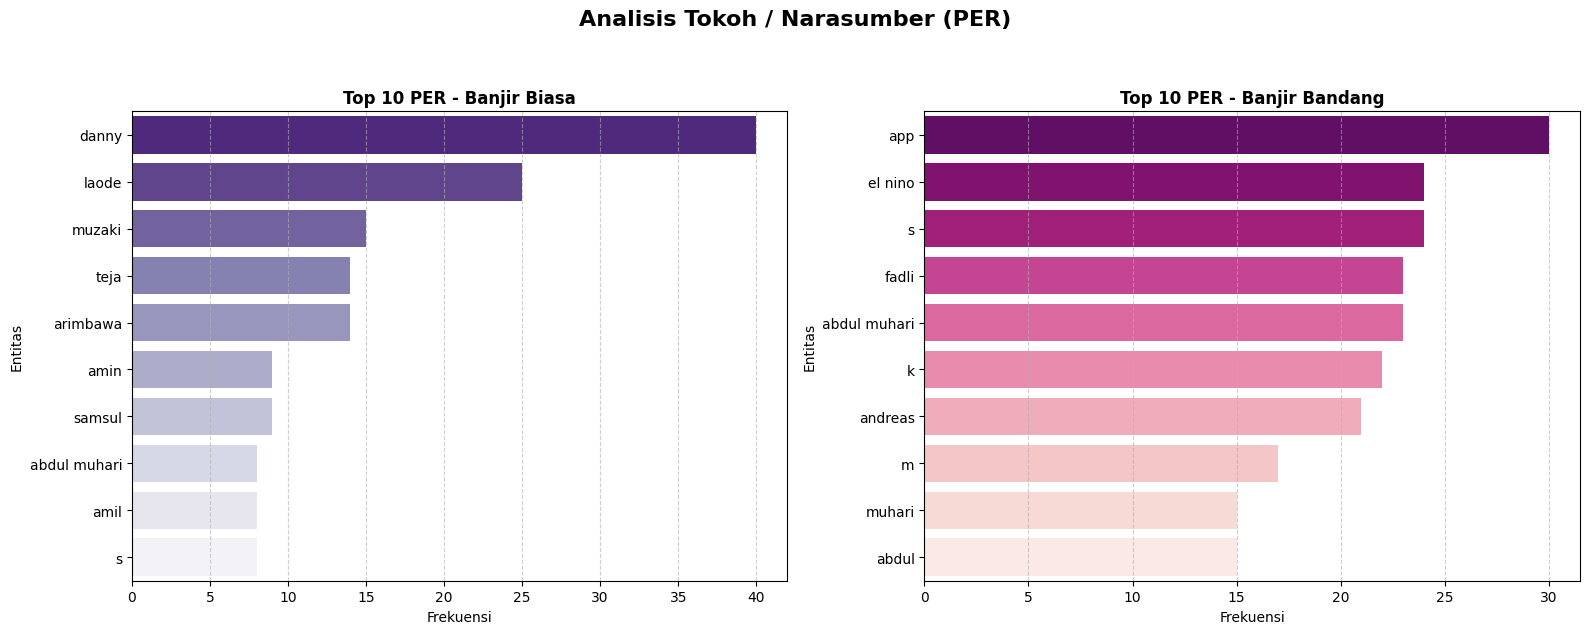

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Tokoh / Narasumber (PER)', fontsize=16, fontweight='bold', y=1.05)

# Kiri: Biasa, Kanan: Bandang
plot_ner_comparison(df_ner_banjir, 'PER', 'Banjir Biasa', axes[0], 'Purples_r')
plot_ner_comparison(df_ner_bandang, 'PER', 'Banjir Bandang', axes[1], 'RdPu_r')

plt.tight_layout()
plt.show()

**N-Grams**

In [10]:
import pandas as pd
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Download resource pendukung
nltk.download('punkt')

def get_top_ngrams(corpus, n=None, top_k=15):
    """Fungsi untuk mengekstrak n-grams dari kolom After_lemma"""
    words = " ".join(corpus.astype(str)).split()
    n_grams = ngrams(words, n)
    counts = Counter(n_grams)
    return counts.most_common(top_k)

def plot_ngrams(ngram_data, title, color_palette='magma'):
    """Fungsi untuk visualisasi grafik batang"""
    if not ngram_data:
        return
    labels = [" ".join(item[0]) for item in ngram_data]
    counts = [item[1] for item in ngram_data]

    plt.figure(figsize=(10, 7))
    sns.barplot(x=counts, y=labels, hue=labels, palette=color_palette, legend=False)
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel('Frekuensi Muncul')
    plt.ylabel('Kata/Frasa')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Memproses Unigrams...


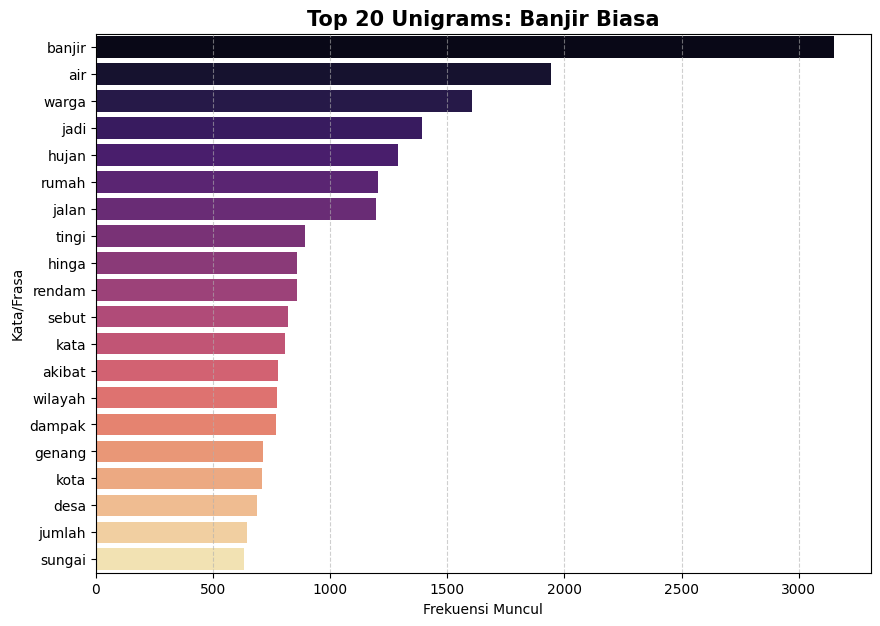

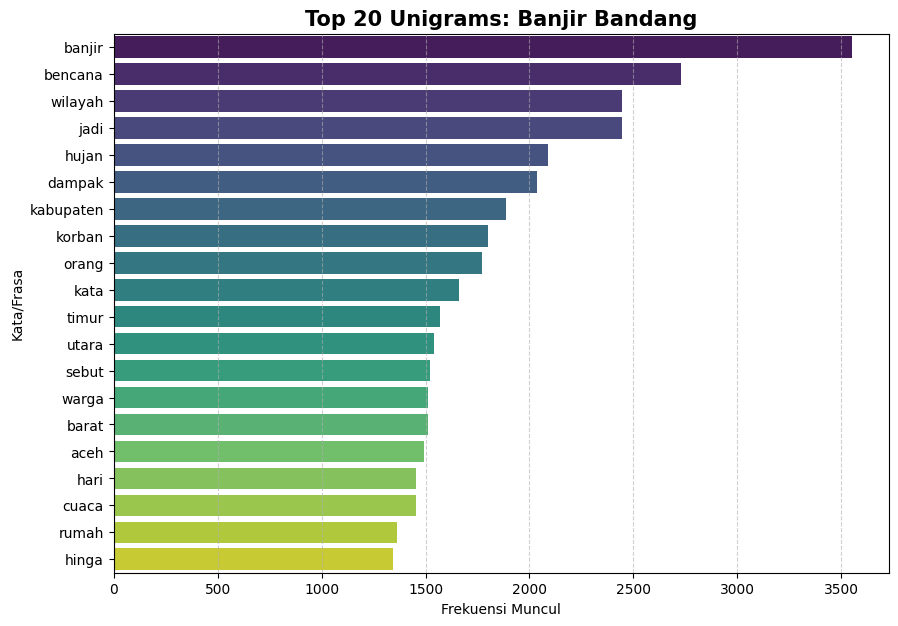

In [11]:
print("Memproses Unigrams...")

# Visualisasi untuk Banjir Biasa menggunakan kolom After_lemma
top_1_biasa = get_top_ngrams(df_sentimen_banjir['After_lemma'], n=1, top_k=20)
plot_ngrams(top_1_biasa, "Top 20 Unigrams: Banjir Biasa", 'magma')

# Visualisasi untuk Banjir Bandang menggunakan kolom After_lemma
top_1_bandang = get_top_ngrams(df_sentimen_bandang['After_lemma'], n=1, top_k=20)
plot_ngrams(top_1_bandang, "Top 20 Unigrams: Banjir Bandang", 'viridis')

Memproses Bigrams...


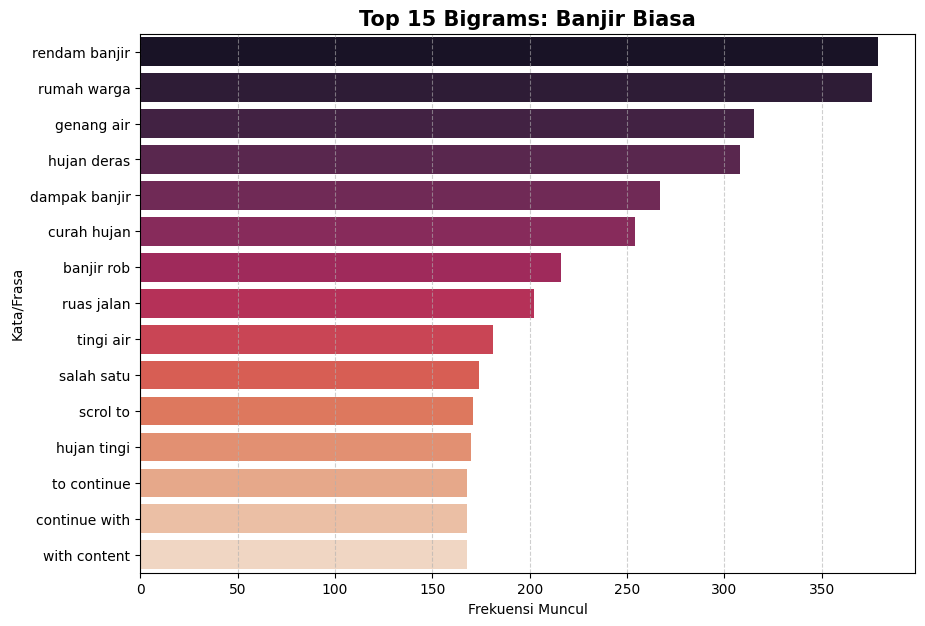

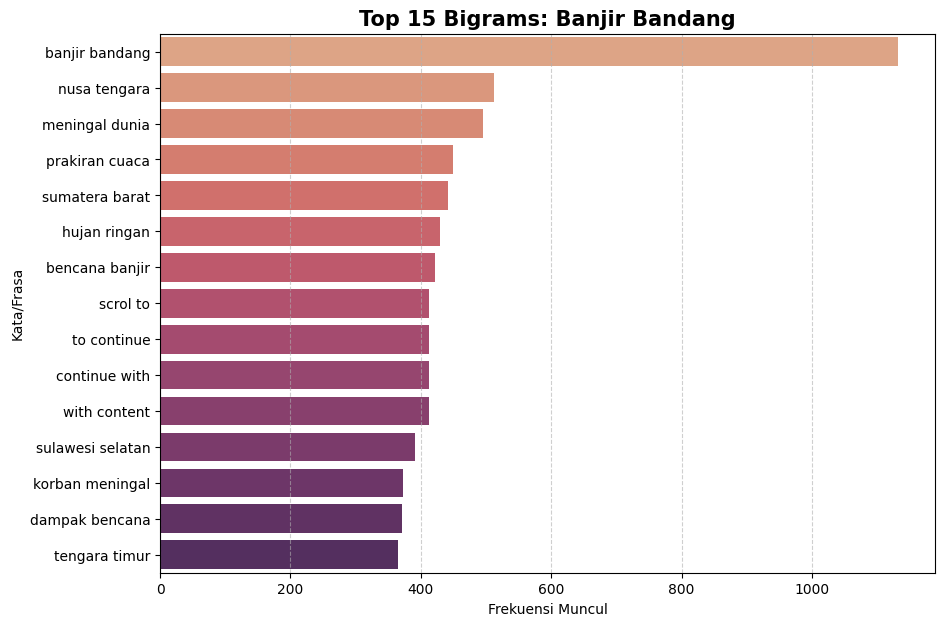

In [12]:
print("Memproses Bigrams...")

# Visualisasi untuk Banjir Biasa[cite: 1]
top_2_biasa = get_top_ngrams(df_sentimen_banjir['After_lemma'], n=2, top_k=15)
plot_ngrams(top_2_biasa, "Top 15 Bigrams: Banjir Biasa", 'rocket')

# Visualisasi untuk Banjir Bandang[cite: 1]
top_2_bandang = get_top_ngrams(df_sentimen_bandang['After_lemma'], n=2, top_k=15)
plot_ngrams(top_2_bandang, "Top 15 Bigrams: Banjir Bandang", 'flare')

Memproses Trigrams...


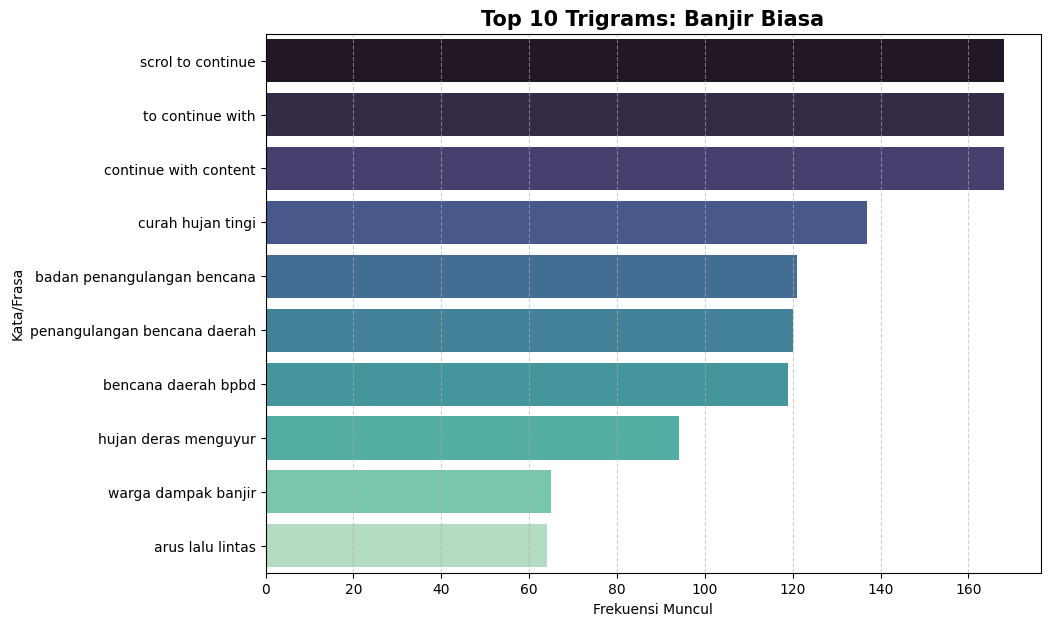

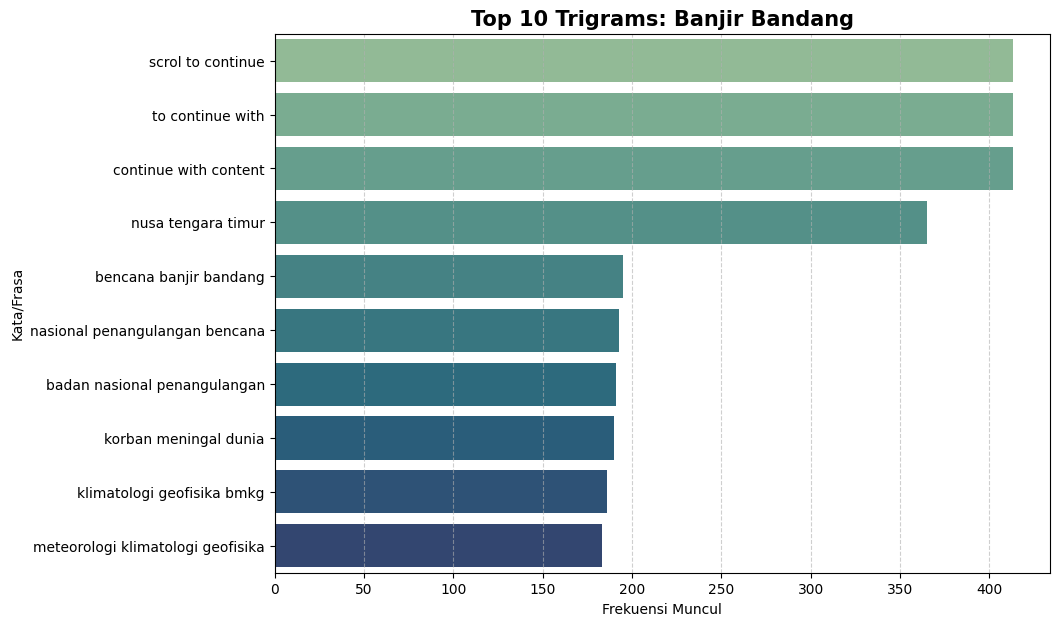

In [13]:
print("Memproses Trigrams...")

# Visualisasi untuk Banjir Biasa[cite: 1]
top_3_biasa = get_top_ngrams(df_sentimen_banjir['After_lemma'], n=3, top_k=10)
plot_ngrams(top_3_biasa, "Top 10 Trigrams: Banjir Biasa", 'mako')

# Visualisasi untuk Banjir Bandang[cite: 1]
top_3_bandang = get_top_ngrams(df_sentimen_bandang['After_lemma'], n=3, top_k=10)
plot_ngrams(top_3_bandang, "Top 10 Trigrams: Banjir Bandang", 'crest')